# 5.3 Evaluation

This notebook performs the final evaluation of all three trained models against the NSL-KDD test set.

**Contents:**
1. Reload preprocessed data and retrain models
2. Per-model classification reports
3. ROC curves + AUC
4. Precision-Recall curves + Average Precision
5. Radar chart — multi-metric visual comparison
6. Final comparison table (metrics + stability)
7. Interpretation — which model wins and why

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from src.preprocess import preprocess
from src.train import train_knn, train_nb, train_svm, stability_analysis
from src.evaluate import (
    metrics_summary,
    plot_roc,
    plot_pr,
    final_comparison_table,
    print_classification_reports,
    plot_radar,
    interpret_results,
)

sns.set_theme(style="whitegrid", palette="muted")
REPORT_DIR = "../reports"
os.makedirs(REPORT_DIR, exist_ok=True)
print('Imports OK')

Imports OK


## Step 1 — Load Data

Load from `data/processed/` — already preprocessed in notebook 5.1.

In [3]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"y_train: {y_train.value_counts().to_dict()}")
print(f"y_test : {y_test.value_counts().to_dict()}")

X_train: (125973, 41)  X_test: (22543, 41)
y_train: {0: 67343, 1: 58630}
y_test : {1: 12833, 0: 9710}


## Step 2 — Retrain Models

We retrain using the same best hyperparameters found in notebook 5.2.


In [4]:
# KNN — retrain with best K from 5.2 (change if your best_k was different)
knn_model, knn_metrics, knn_cv_scores, best_k = train_knn(
    X_train, y_train, X_test, y_test,
    k_range=range(1, 22, 2)
)

# Naive Bayes
nb_model, nb_metrics = train_nb(X_train, y_train, X_test, y_test)

# SVM
svm_model, svm_metrics, svm_best_params, svm_sample = train_svm(
    X_train, y_train, X_test, y_test,
    sample_size=25000, cv=3
)

[tune_knn] Testing K = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21] with 5-fold CV...
  K= 1  F1=0.9963 ± 0.0004
  K= 3  F1=0.9955 ± 0.0003
  K= 5  F1=0.9950 ± 0.0003
  K= 7  F1=0.9943 ± 0.0004
  K= 9  F1=0.9935 ± 0.0003
  K=11  F1=0.9930 ± 0.0006
  K=13  F1=0.9928 ± 0.0006
  K=15  F1=0.9925 ± 0.0006
  K=17  F1=0.9923 ± 0.0008
  K=19  F1=0.9921 ± 0.0006
  K=21  F1=0.9917 ± 0.0008

[tune_knn] Best K = 1  (F1 = 0.9963)

[train_knn] Fitting KNN with K=1...
[train_knn] Test results → Acc: 0.7924  P: 0.9743  R: 0.6526  F1: 0.7817
[train_nb] Fitting Gaussian Naive Bayes...
[train_nb] Test results → Acc: 0.7709  P: 0.9161  R: 0.6578  F1: 0.7657
[train_svm] Sample size: 25,000  (Normal: 13,365  Attack: 11,635)
[train_svm] Running GridSearchCV (3-fold)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
[train_svm] Best params: {'C': 10, 'gamma': 'scale'}  (CV F1 = 0.9838)
[train_svm] Test results → Acc: 0.7932  P: 0.9739  R: 0.6542  F1: 0.7826


## Step 3 — Classification Reports

Detailed per-class breakdown showing precision, recall, and F1 for both Normal and Attack classes separately.

In [5]:
predictions = {
    "KNN":         knn_metrics["y_pred"],
    "Naive Bayes": nb_metrics["y_pred"],
    "SVM":         svm_metrics["y_pred"],
}

print_classification_reports(y_test, predictions)


  KNN
              precision    recall  f1-score   support

  Normal (0)       0.68      0.98      0.80      9710
  Attack (1)       0.97      0.65      0.78     12833

    accuracy                           0.79     22543
   macro avg       0.83      0.81      0.79     22543
weighted avg       0.85      0.79      0.79     22543


  Naive Bayes
              precision    recall  f1-score   support

  Normal (0)       0.67      0.92      0.78      9710
  Attack (1)       0.92      0.66      0.77     12833

    accuracy                           0.77     22543
   macro avg       0.79      0.79      0.77     22543
weighted avg       0.81      0.77      0.77     22543


  SVM
              precision    recall  f1-score   support

  Normal (0)       0.68      0.98      0.80      9710
  Attack (1)       0.97      0.65      0.78     12833

    accuracy                           0.79     22543
   macro avg       0.83      0.82      0.79     22543
weighted avg       0.85      0.79      0.79  

## Step 4 — ROC Curves

ROC (Receiver Operating Characteristic) curves plot True Positive Rate vs False Positive Rate at every classification threshold. AUC (Area Under Curve) summarises performance in a single number — 1.0 = perfect, 0.5 = random.

**Note on SVM:** `SVC` with default settings does not produce probability estimates. We use `decision_function()` which returns a signed distance from the decision boundary — a valid ranking score for ROC/PR computation.

[plot_roc] Saved → ../reports/roc_curves.png


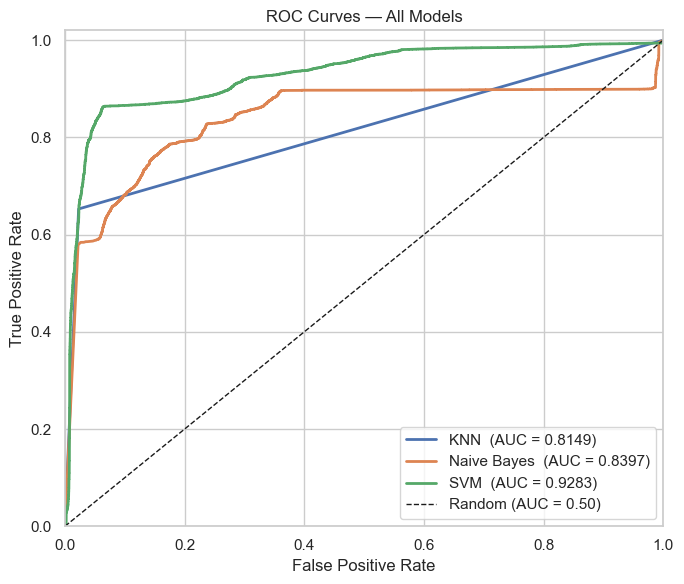


AUC Scores:
  KNN            : 0.8149
  Naive Bayes    : 0.8397
  SVM            : 0.9283


In [6]:
# Get probability / score estimates for each model
proba_dict = {
    "KNN":         knn_model.predict_proba(X_test)[:, 1],
    "Naive Bayes": nb_model.predict_proba(X_test)[:, 1],
    "SVM":         svm_model.decision_function(X_test),   # signed distance
}

auc_scores = plot_roc(
    y_test, proba_dict,
    save_path=f"{REPORT_DIR}/roc_curves.png"
)

print("\nAUC Scores:")
for name, score in auc_scores.items():
    print(f"  {name:15s}: {score:.4f}")

## Step 5 — Precision-Recall Curves

PR curves are particularly relevant for intrusion detection because:
- **Recall** (y-axis at threshold=0.5) = fraction of actual attacks detected → our priority metric
- **Precision** = fraction of flagged connections that are truly attacks → false alarm rate

A model can achieve high Recall by flagging everything, but precision collapses. A good NIDS needs both to be high. **Average Precision (AP)** summarises the area under the PR curve.

[plot_pr] Saved → ../reports/pr_curves.png


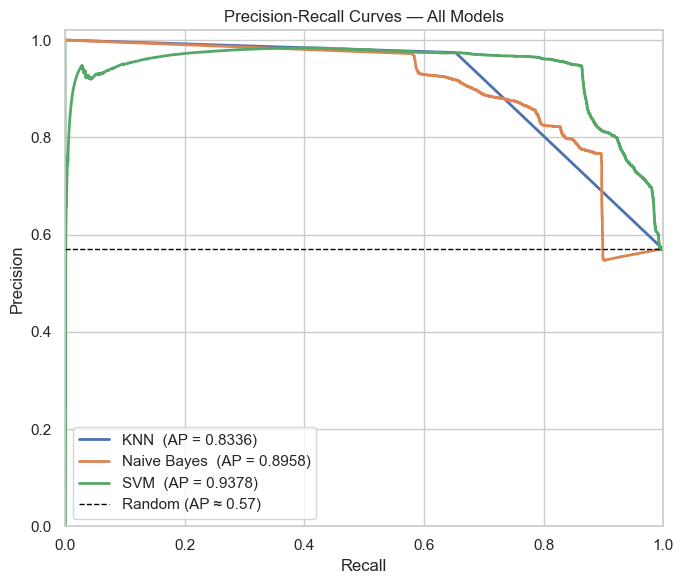


Average Precision Scores:
  KNN            : 0.8336
  Naive Bayes    : 0.8958
  SVM            : 0.9378


In [7]:
ap_scores = plot_pr(
    y_test, proba_dict,
    save_path=f"{REPORT_DIR}/pr_curves.png"
)

print("\nAverage Precision Scores:")
for name, score in ap_scores.items():
    print(f"  {name:15s}: {score:.4f}")

## Step 6 — Stability Analysis

Repeated Stratified K-Fold (10×5 = 50 evaluations per model) measures how consistent each model's F1 is across different data splits.

**CV% (Coefficient of Variation)** = std / mean × 100
- CV% < 2% → very stable
- CV% 2–5% → acceptable
- CV% > 5% → unstable

In [8]:
stability_models = {
    "KNN":         KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "SVM":         SVC(kernel="rbf",
                       C=svm_best_params["C"],
                       gamma=svm_best_params["gamma"],
                       class_weight="balanced",
                       random_state=42),
}

stability_df, raw_scores = stability_analysis(
    stability_models, X_train, y_train,
    n_splits=5, n_repeats=10,
    scoring="f1", svm_sample_size=25000
)

print("\nStability Summary:")
print(stability_df.set_index("Model").to_string())

[stability] Running 10×5-fold CV for KNN...
  → Mean=0.9965  Std=0.0004  CV%=0.04%
[stability] Running 10×5-fold CV for Naive Bayes...
  → Mean=0.8888  Std=0.0042  CV%=0.47%
[stability] Running 10×5-fold CV for SVM...
  → Mean=0.9848  Std=0.0015  CV%=0.15%

Stability Summary:
             Mean F1     Std     Min     Max   CV%  n_evals
Model                                                      
KNN           0.9965  0.0004  0.9956  0.9974  0.04       50
Naive Bayes   0.8888  0.0042  0.8790  0.8953  0.47       50
SVM           0.9848  0.0015  0.9825  0.9894  0.15       50


## Step 7 — Radar Chart

[plot_radar] Saved → ../reports/radar_chart.png


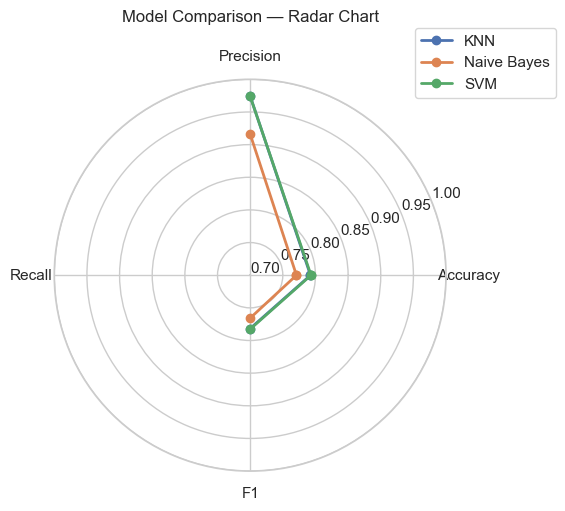

In [9]:
metrics_df = metrics_summary(y_test, predictions)

plot_radar(
    metrics_df,
    save_path=f"{REPORT_DIR}/radar_chart.png"
)

## Step 8 — Final Comparison Table

In [10]:
table = final_comparison_table(
    metrics_df, stability_df, auc_scores, ap_scores
)

print("Final Comparison Table:")
print(table.round(4).to_string())

# Save as CSV for the report
table.round(4).to_csv(f"{REPORT_DIR}/final_comparison_table.csv")
print(f"\nSaved → {REPORT_DIR}/final_comparison_table.csv")

Final Comparison Table:
             Accuracy  Precision  Recall      F1     AUC  Avg Precision  CV Mean F1  CV Std   CV%
Model                                                                                            
KNN            0.7924     0.9743  0.6526  0.7817  0.8149         0.8336      0.9965  0.0004  0.04
Naive Bayes    0.7709     0.9161  0.6578  0.7657  0.8397         0.8958      0.8888  0.0042  0.47
SVM            0.7932     0.9739  0.6542  0.7826  0.9283         0.9378      0.9848  0.0015  0.15

Saved → ../reports/final_comparison_table.csv


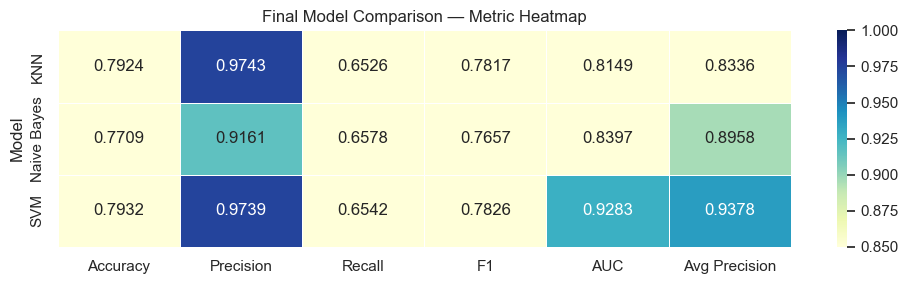

In [11]:
# Heatmap version of the table (great for the report)
plot_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC", "Avg Precision"]

fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(
    table[plot_cols].astype(float),
    annot=True, fmt=".4f", cmap="YlGnBu",
    linewidths=0.5, ax=ax,
    vmin=0.85, vmax=1.0
)
ax.set_title("Final Model Comparison — Metric Heatmap")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/final_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 9 — Interpretation

In [12]:
interpret_results(table)


  INTERPRETATION
  Highest F1       : SVM  (0.7826)
  Highest Recall   : Naive Bayes  (0.6578)
  Most Stable      : KNN  (CV% = 0.04%)
  Highest AUC      : SVM  (0.9283)

  NIDS priority metric is Recall (minimise missed attacks).
  → Recommended model: Naive Bayes
  Note: SVM has higher F1 — consider if false alarm
  rate is also a concern in your deployment context.


---
## Summary of All Outputs

In [13]:
all_reports = [
    "feature_groups.png",
    "class_balance.png",
    "scaling_example.png",
    "knn_k_selection.png",
    "model_comparison.png",
    "confusion_matrices.png",
    "stability_boxplot.png",
    "learning_curves.png",
    "roc_curves.png",
    "pr_curves.png",
    "radar_chart.png",
    "final_heatmap.png",
    "final_comparison_table.csv",
]

print("=" * 50)
print("  PROJECT COMPLETE — All outputs in reports/")
print("=" * 50)
for f in all_reports:
    path = f"{REPORT_DIR}/{f}"
    status = "✅" if os.path.exists(path) else "❌ missing"
    print(f"  {status}  {f}")
print("=" * 50)

  PROJECT COMPLETE — All outputs in reports/
  ✅  feature_groups.png
  ✅  class_balance.png
  ✅  scaling_example.png
  ✅  knn_k_selection.png
  ✅  model_comparison.png
  ✅  confusion_matrices.png
  ✅  stability_boxplot.png
  ✅  learning_curves.png
  ✅  roc_curves.png
  ✅  pr_curves.png
  ✅  radar_chart.png
  ✅  final_heatmap.png
  ✅  final_comparison_table.csv
